# 04 — Integración de Resultados y Síntesis del EDA

**Dataset:** AI Dependency, Career Anxiety and Student Burnout  
**Variable objetivo del EDA relacional:** `burnout_score`  
**Variable objetivo del metadata:** `overall_career_readiness_score`  

Este notebook integra los hallazgos de los análisis previos:

| Notebook | Etapa |
|----------|-------|
| `01_calidad_datos.ipynb` | Comprensión y calidad de datos |
| `02_analisis_univariado.ipynb` | Análisis univariado |
| `03_relacion_variables.ipynb` | Análisis relacional / bivariado |

**Responsabilidad de esta etapa:** Reunir hallazgos, ordenar los resultados más importantes, redactar conclusiones del EDA, identificar limitaciones del dataset, proponer próximos pasos y recomendar una problemática de reglas de asociación viable.

---
## 1. Configuración y carga de artefactos

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display, Markdown, Image

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 130, "savefig.dpi": 150, "figure.facecolor": "white"})

# ── Rutas ────────────────────────────────────────────────────────────────────
PROJECT = Path("..").resolve()
TABLAS  = PROJECT / "outputs" / "tablas"
GRAFICOS = PROJECT / "outputs" / "graficos"
REPORTES = PROJECT / "outputs" / "reportes"

# ── Dataset limpio ────────────────────────────────────────────────────────────
df = pd.read_csv(PROJECT / "data" / "processed" / "dataset_limpio.csv")
print(f"Dataset limpio: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Dataset limpio: 11,119 filas × 30 columnas


In [2]:
# ── Tablas generadas en notebooks anteriores ─────────────────────────────────
stats_df       = pd.read_csv(TABLAS / "estadisticas_descriptivas.csv")
outliers_df    = pd.read_csv(TABLAS / "reporte_outliers.csv")
forma_df       = pd.read_csv(TABLAS / "forma_distribuciones.csv")
ranking_df     = pd.read_csv(TABLAS / "ranking_correlaciones_burnout.csv")
candidatas_df  = pd.read_csv(TABLAS / "variables_candidatas_modelamiento.csv")
baja_var_df    = pd.read_csv(TABLAS / "baja_variabilidad.csv")

# Tablas de comparación por grupo
grupo_archivos = sorted(TABLAS.glob("burnout_por_*.csv"))
grupos = {p.stem.replace("burnout_por_", ""): pd.read_csv(p) for p in grupo_archivos}

print("Tablas cargadas:", len(grupo_archivos), "comparaciones de grupo")
print("Variables candidatas:", len(candidatas_df))

# ── Verificar nombres de columnas cargados ───────────────────────────────────
print("\nColumnas outliers:", list(outliers_df.columns))
print("Columnas forma:", list(forma_df.columns))
print("Columnas stats:", list(stats_df.columns))

Tablas cargadas: 11 comparaciones de grupo
Variables candidatas: 23

Columnas outliers: ['Variable', 'Límite inf.', 'Límite sup.', 'N outliers', '% outliers']
Columnas forma: ['Variable', 'Asimetría', 'Curtosis', 'Forma']
Columnas stats: ['Variable', 'Media', 'Mediana', 'Mínimo', 'Máximo', 'Desv_std', 'P25', 'P75', 'P90']


---
## 2. Síntesis de calidad de datos

### 2.1 Resumen del estado del dataset

In [3]:
n_raw = 15_000  # según metadata
n_clean = len(df)
n_removed = n_raw - n_clean
pct_removed = n_removed / n_raw * 100

calidad_resumen = pd.DataFrame({
    "Métrica": [
        "Registros originales",
        "Registros tras limpieza",
        "Registros eliminados",
        "% eliminado",
        "Variables",
        "Variables numéricas",
        "Variables categóricas",
        "Duplicados exactos encontrados",
        "Variables con baja variabilidad",
    ],
    "Valor": [
        f"{n_raw:,}",
        f"{n_clean:,}",
        f"{n_removed:,}",
        f"{pct_removed:.1f}%",
        str(df.shape[1]),
        str(df.select_dtypes(include='number').shape[1]),
        str(df.select_dtypes(exclude='number').shape[1]),
        "0",
        str(len(baja_var_df)),
    ]
})

display(Markdown("### Resumen de calidad del dataset"))
display(calidad_resumen.style.hide(axis='index'))

### Resumen de calidad del dataset

Métrica,Valor
Registros originales,"15,000"
Registros tras limpieza,"11,119"
Registros eliminados,"3,881"
% eliminado,25.9%
Variables,30
Variables numéricas,22
Variables categóricas,8
Duplicados exactos encontrados,0
Variables con baja variabilidad,0


In [4]:
# Variables que tenían nulos en el dataset original
nulos_orig = pd.DataFrame({
    "Variable": ["primary_ai_tools_used", "self_learning_hours_per_week",
                 "social_media_hrs_per_day", "sleep_hours", "seeks_career_counseling"],
    "Nulos": [3215, 233, 210, 203, 220],
    "% del total": [f"{x/n_raw*100:.1f}%" for x in [3215, 233, 210, 203, 220]],
    "Tratamiento": ["Eliminación de filas con NA"] * 5
})

display(Markdown("### Variables con valores nulos (pre-limpieza)"))
display(nulos_orig.style.hide(axis='index'))

display(Markdown(
    f"> **Nota:** Se eliminaron {n_removed:,} filas ({pct_removed:.1f}%) por presencia de valores nulos. "
    f"`primary_ai_tools_used` fue la variable con mayor proporción de datos faltantes (21.4%). "
    f"El dataset resultante mantiene {n_clean:,} registros, cantidad suficiente para análisis descriptivo y modelamiento."
))

### Variables con valores nulos (pre-limpieza)

Variable,Nulos,% del total,Tratamiento
primary_ai_tools_used,3215,21.4%,Eliminación de filas con NA
self_learning_hours_per_week,233,1.6%,Eliminación de filas con NA
social_media_hrs_per_day,210,1.4%,Eliminación de filas con NA
sleep_hours,203,1.4%,Eliminación de filas con NA
seeks_career_counseling,220,1.5%,Eliminación de filas con NA


> **Nota:** Se eliminaron 3,881 filas (25.9%) por presencia de valores nulos. `primary_ai_tools_used` fue la variable con mayor proporción de datos faltantes (21.4%). El dataset resultante mantiene 11,119 registros, cantidad suficiente para análisis descriptivo y modelamiento.

---
## 3. Hallazgos principales del análisis univariado

### 3.1 Panorama de distribuciones

In [5]:
# Tabla resumen de la forma de las distribuciones
forma_count = forma_df["Forma"].value_counts().reset_index()
forma_count.columns = ["Forma de distribución", "N° de variables"]

display(Markdown("### Clasificación de distribuciones"))
display(forma_count.style.hide(axis='index'))

# Variables con sesgo notable
col_asimetria = [c for c in forma_df.columns if 'simetr' in c.lower() or 'asimetr' in c.lower()][0]
sesgadas = forma_df[forma_df["Forma"] != "Aproximadamente simétrica"][["Variable", col_asimetria, "Forma"]]
display(Markdown("### Variables con sesgo"))
display(sesgadas.style.hide(axis='index').format({col_asimetria: "{:.3f}"}))

### Clasificación de distribuciones

Forma de distribución,N° de variables
Aproximadamente simétrica,16
Sesgo derecho,5
Sesgo izquierdo,1


### Variables con sesgo

Variable,Asimetría,Forma
age,0.723,Sesgo derecho
daily_ai_tool_usage_hrs,0.643,Sesgo derecho
fear_of_job_loss_to_ai,-0.516,Sesgo izquierdo
self_learning_hours_per_week,0.560,Sesgo derecho
skill_development_courses_taken,0.982,Sesgo derecho
seeks_career_counseling,0.919,Sesgo derecho


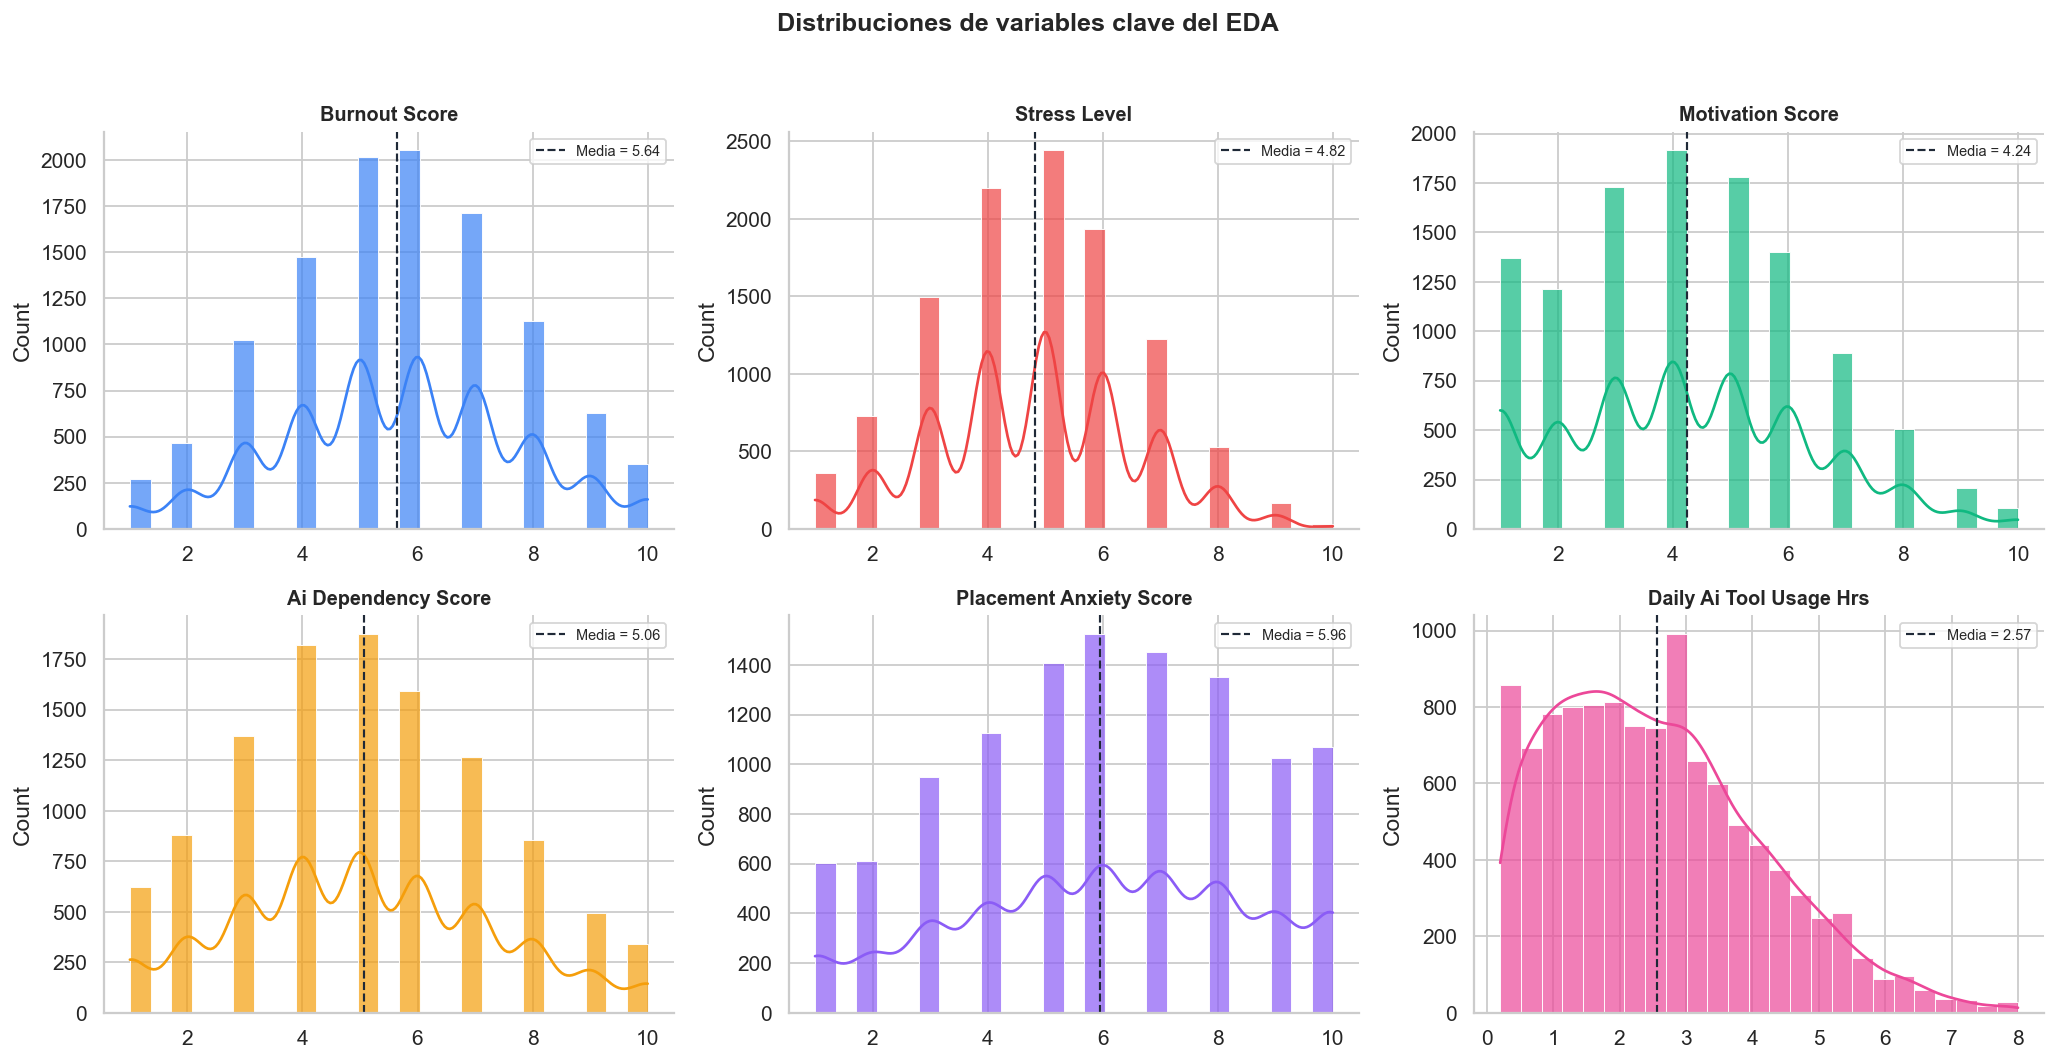

In [6]:
# ── Panel resumen: distribuciones clave del EDA ──────────────────────────────
key_vars = ["burnout_score", "stress_level", "motivation_score",
            "ai_dependency_score", "placement_anxiety_score", "daily_ai_tool_usage_hrs"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
colors = ["#3B82F6", "#EF4444", "#10B981", "#F59E0B", "#8B5CF6", "#EC4899"]

for ax, col, color in zip(axes.ravel(), key_vars, colors):
    sns.histplot(df[col], bins=25, kde=True, color=color,
                 edgecolor="white", linewidth=0.5, alpha=0.7, ax=ax)
    mean_val = df[col].mean()
    ax.axvline(mean_val, color="#1F2937", linestyle="--", linewidth=1.2, label=f"Media = {mean_val:.2f}")
    ax.set_title(col.replace("_", " ").title(), fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

fig.suptitle("Distribuciones de variables clave del EDA", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(GRAFICOS / "panel_variables_clave.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.2 Valores atípicos (outliers)

In [7]:
# Detectar nombres de columnas dinámicamente (pueden tener acentos)
col_pct = [c for c in outliers_df.columns if 'outlier' in c.lower() and '%' in c.lower()]
col_pct = col_pct[0] if col_pct else "% outliers"
col_linf = [c for c in outliers_df.columns if 'inf' in c.lower()]
col_linf = col_linf[0] if col_linf else "Límite inf."
col_lsup = [c for c in outliers_df.columns if 'sup' in c.lower()]
col_lsup = col_lsup[0] if col_lsup else "Límite sup."

# Variables con outliers
outliers_relevantes = outliers_df[outliers_df[col_pct] > 0].sort_values(col_pct, ascending=False)

display(Markdown("### Variables con outliers detectados (regla IQR)"))
display(outliers_relevantes.style.hide(axis='index').format({
    col_pct: "{:.2f}%",
    col_linf: "{:.2f}",
    col_lsup: "{:.2f}"
}))

display(Markdown(
    "> **Interpretación:** Los outliers son moderados. `internship_experience` tiene la mayor "
    "proporción (5.24%) debido a que la mayoría de estudiantes reporta 0-2 pasantías y unos pocos reportan 4. "
    "`age` presenta 4.06% de outliers en los extremos superiores (>25 años). "
    "En general, los outliers no representan errores de captura sino variabilidad natural de la población."
))

### Variables con outliers detectados (regla IQR)

Variable,Límite inf.,Límite sup.,N outliers,% outliers
internship_experience,-0.50,3.50,583,5.24%
age,17.00,25.00,451,4.06%
skill_development_courses_taken,-2.00,6.00,237,2.13%
daily_ai_tool_usage_hrs,-2.08,6.92,88,0.79%
daily_study_hours,-2.60,7.80,54,0.49%
sleep_hours,4.20,9.80,52,0.47%
social_media_hrs_per_day,-1.65,7.55,52,0.47%
self_learning_hours_per_week,-10.50,23.90,40,0.36%
weekly_job_application_count,-7.50,28.50,40,0.36%
stress_level,1.00,9.00,33,0.30%


> **Interpretación:** Los outliers son moderados. `internship_experience` tiene la mayor proporción (5.24%) debido a que la mayoría de estudiantes reporta 0-2 pasantías y unos pocos reportan 4. `age` presenta 4.06% de outliers en los extremos superiores (>25 años). En general, los outliers no representan errores de captura sino variabilidad natural de la población.

### 3.3 Estadísticas descriptivas de variables clave

In [8]:
key_stats = stats_df[stats_df["Variable"].isin(key_vars)].copy()

# Detectar nombres de columnas con acentos dinámicamente
col_min = [c for c in stats_df.columns if 'nim' in c.lower() or 'min' in c.lower()]
col_min = col_min[0] if col_min else "Mínimo"
col_max = [c for c in stats_df.columns if 'xim' in c.lower() or 'max' in c.lower()]
col_max = col_max[0] if col_max else "Máximo"

fmt_dict = {
    "Media": "{:.2f}", "Mediana": "{:.2f}", col_min: "{:.1f}",
    col_max: "{:.1f}", "Desv_std": "{:.2f}", "P25": "{:.2f}",
    "P75": "{:.2f}", "P90": "{:.2f}"
}

display(Markdown("### Estadísticas descriptivas — variables principales"))
display(key_stats.style.hide(axis='index').format(fmt_dict))

### Estadísticas descriptivas — variables principales

Variable,Media,Mediana,Mínimo,Máximo,Desv_std,P25,P75,P90
daily_ai_tool_usage_hrs,2.57,2.40,0.2,8.0,1.57,1.30,3.55,4.80
ai_dependency_score,5.06,5.00,1.0,10.0,2.24,3.00,7.00,8.00
placement_anxiety_score,5.96,6.00,1.0,10.0,2.55,4.00,8.00,9.00
stress_level,4.82,5.00,1.0,10.0,1.78,4.00,6.00,7.00
burnout_score,5.64,6.00,1.0,10.0,2.06,4.00,7.00,8.00
motivation_score,4.24,4.00,1.0,10.0,2.13,3.00,6.00,7.00


---
## 4. Hallazgos principales del análisis relacional

### 4.1 Ranking de correlaciones con `burnout_score`

In [9]:
display(Markdown("### Correlaciones de Spearman con burnout_score (Top 10)"))
top10 = ranking_df.head(10)[["variable", "correlacion_spearman", "bloque"]].copy()
display(top10.style.hide(axis='index').format({"correlacion_spearman": "{:.3f}"}))

### Correlaciones de Spearman con burnout_score (Top 10)

variable,correlacion_spearman,bloque
stress_level,0.577,Subjetiva / autopercepción
motivation_score,-0.524,Subjetiva / autopercepción
seeks_career_counseling,0.386,Conductual / hábitos
placement_anxiety_score,0.370,Subjetiva / autopercepción
interview_anxiety_score,0.356,Subjetiva / autopercepción
fear_of_job_loss_to_ai,0.355,Subjetiva / autopercepción
ai_dependency_score,0.351,Subjetiva / autopercepción
ai_replaces_own_thinking_score,0.243,Subjetiva / autopercepción
daily_ai_tool_usage_hrs,0.225,Conductual / hábitos
career_clarity_score,-0.178,Subjetiva / autopercepción


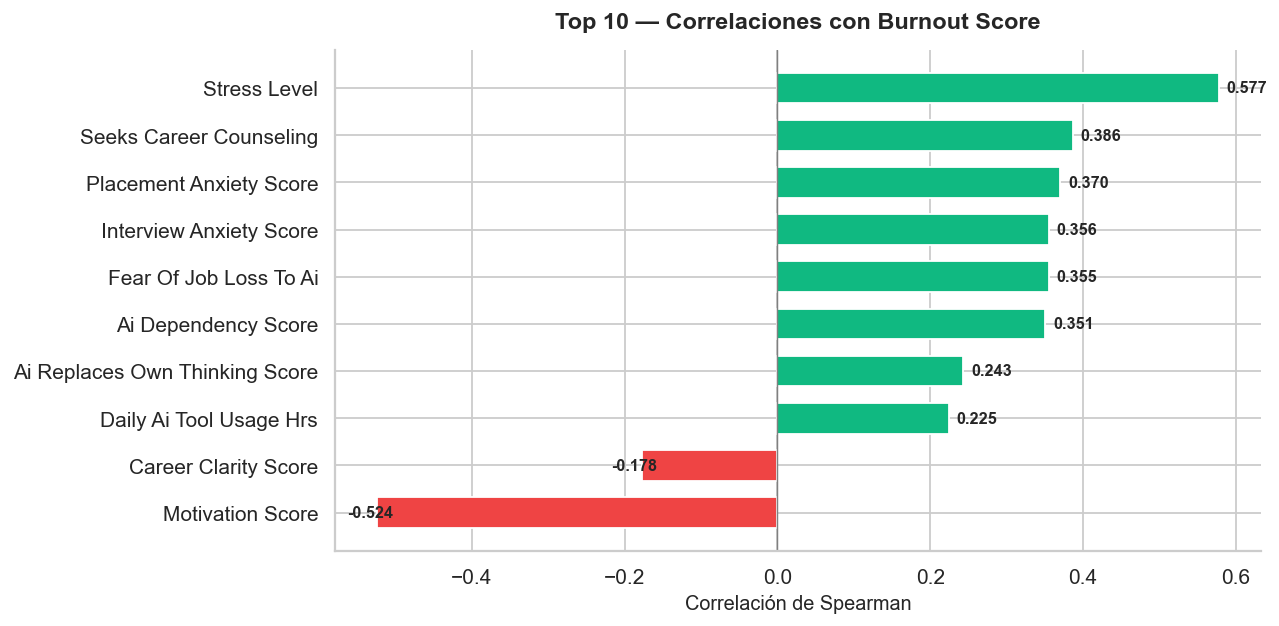

In [10]:
# ── Gráfico resumen: Top 10 correlaciones con burnout ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
top10_plot = ranking_df.head(10).sort_values("correlacion_spearman")

colors_bar = ["#10B981" if v > 0 else "#EF4444" for v in top10_plot["correlacion_spearman"]]

bars = ax.barh(top10_plot["variable"].str.replace("_", " ").str.title(),
               top10_plot["correlacion_spearman"],
               color=colors_bar, edgecolor="white", height=0.65)

for bar, val in zip(bars, top10_plot["correlacion_spearman"]):
    offset = 0.01 if val >= 0 else -0.04
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9, fontweight="bold")

ax.axvline(0, color="grey", linewidth=0.8, linestyle="-")
ax.set_xlabel("Correlación de Spearman", fontsize=11)
ax.set_title("Top 10 — Correlaciones con Burnout Score", fontsize=13, fontweight="bold", pad=12)
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(GRAFICOS / "top10_correlaciones_burnout.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.2 Patrones principales por bloque conceptual

In [11]:
display(Markdown("""
#### Bloque 1 — Variables subjetivas / autopercepción

Las relaciones más fuertes con `burnout_score` provienen de este bloque:

| Variable | ρ Spearman | Interpretación |
|----------|-----------|----------------|
| `stress_level` | **+0.577** | Relación fuerte y positiva. Mayor estrés → mayor burnout. Esperable conceptualmente. |
| `motivation_score` | **−0.524** | Relación negativa. Menor motivación → mayor burnout. Confirma la literatura. |
| `placement_anxiety_score` | **+0.370** | Ansiedad por inserción laboral; contribuye al agotamiento. |
| `interview_anxiety_score` | **+0.356** | Similar a la anterior; ansiedad ante entrevistas. |
| `fear_of_job_loss_to_ai` | **+0.355** | Miedo al desplazamiento por IA; conecta tecnología con ansiedad laboral. |
| `ai_dependency_score` | **+0.351** | Eje central: mayor dependencia de IA → mayor burnout. |

> **Conclusión del bloque:** Las variables de autopercepción dominan la relación con burnout. Esto era esperable porque miden constructos cercanos. Sin embargo, confirman la estructura interna del dataset.
"""))

display(Markdown("""
#### Bloque 2 — Variables conductuales / hábitos

| Variable | ρ Spearman | Interpretación |
|----------|-----------|----------------|
| `seeks_career_counseling` | **+0.386** | Quienes buscan orientación profesional tienden a presentar mayor burnout (puede ser consecuencia, no causa). |
| `daily_ai_tool_usage_hrs` | **+0.225** | Más horas de uso de IA → mayor burnout. Relación moderada-baja. |
| `sleep_hours` | **−0.167** | Más sueño → menor burnout. Factor protector. |
| `internship_experience` | **−0.151** | Más experiencia práctica → menor burnout. |
| `weekly_job_application_count` | **+0.144** | Mayor búsqueda laboral → mayor burnout (presión). |

> **Conclusión del bloque:** Estas variables aportan información adicional y no redundante. Son candidatas ideales para reglas de asociación porque reflejan comportamientos observables.
"""))

display(Markdown("""
#### Bloque 3 — Variables contextuales / demográficas

| Variable | Diferencia medias (burnout) | Interpretación |
|----------|---------------------------|----------------|
| `uses_ai_for_assignments` | **1.64** | Los que usan IA "Always" tienen burnout promedio de 6.64 vs 5.00 de "Never". |
| `primary_ai_tools_used` | **0.87** | GitHub Copilot presenta el mayor burnout promedio (6.34). |
| `stream` | **0.47** | CS/IT muestra mayor burnout (5.87) que otras áreas. |
| `college_tier` | **0.46** | Universidades Tier 3 presentan mayor burnout (5.76) que Tier 1 (5.30). |
| `gender`, `degree_type`, `urban_or_rural` | < 0.10 | Diferencias negligibles; útiles solo como variables de control. |

> **Conclusión del bloque:** `uses_ai_for_assignments` presenta la mayor diferencia entre grupos, lo que la convierte en una variable categórica prioritaria para reglas de asociación.
"""))


#### Bloque 1 — Variables subjetivas / autopercepción

Las relaciones más fuertes con `burnout_score` provienen de este bloque:

| Variable | ρ Spearman | Interpretación |
|----------|-----------|----------------|
| `stress_level` | **+0.577** | Relación fuerte y positiva. Mayor estrés → mayor burnout. Esperable conceptualmente. |
| `motivation_score` | **−0.524** | Relación negativa. Menor motivación → mayor burnout. Confirma la literatura. |
| `placement_anxiety_score` | **+0.370** | Ansiedad por inserción laboral; contribuye al agotamiento. |
| `interview_anxiety_score` | **+0.356** | Similar a la anterior; ansiedad ante entrevistas. |
| `fear_of_job_loss_to_ai` | **+0.355** | Miedo al desplazamiento por IA; conecta tecnología con ansiedad laboral. |
| `ai_dependency_score` | **+0.351** | Eje central: mayor dependencia de IA → mayor burnout. |

> **Conclusión del bloque:** Las variables de autopercepción dominan la relación con burnout. Esto era esperable porque miden constructos cercanos. Sin embargo, confirman la estructura interna del dataset.



#### Bloque 2 — Variables conductuales / hábitos

| Variable | ρ Spearman | Interpretación |
|----------|-----------|----------------|
| `seeks_career_counseling` | **+0.386** | Quienes buscan orientación profesional tienden a presentar mayor burnout (puede ser consecuencia, no causa). |
| `daily_ai_tool_usage_hrs` | **+0.225** | Más horas de uso de IA → mayor burnout. Relación moderada-baja. |
| `sleep_hours` | **−0.167** | Más sueño → menor burnout. Factor protector. |
| `internship_experience` | **−0.151** | Más experiencia práctica → menor burnout. |
| `weekly_job_application_count` | **+0.144** | Mayor búsqueda laboral → mayor burnout (presión). |

> **Conclusión del bloque:** Estas variables aportan información adicional y no redundante. Son candidatas ideales para reglas de asociación porque reflejan comportamientos observables.



#### Bloque 3 — Variables contextuales / demográficas

| Variable | Diferencia medias (burnout) | Interpretación |
|----------|---------------------------|----------------|
| `uses_ai_for_assignments` | **1.64** | Los que usan IA "Always" tienen burnout promedio de 6.64 vs 5.00 de "Never". |
| `primary_ai_tools_used` | **0.87** | GitHub Copilot presenta el mayor burnout promedio (6.34). |
| `stream` | **0.47** | CS/IT muestra mayor burnout (5.87) que otras áreas. |
| `college_tier` | **0.46** | Universidades Tier 3 presentan mayor burnout (5.76) que Tier 1 (5.30). |
| `gender`, `degree_type`, `urban_or_rural` | < 0.10 | Diferencias negligibles; útiles solo como variables de control. |

> **Conclusión del bloque:** `uses_ai_for_assignments` presenta la mayor diferencia entre grupos, lo que la convierte en una variable categórica prioritaria para reglas de asociación.


### 4.3 Mapa de calor — correlaciones entre variables prioritarias

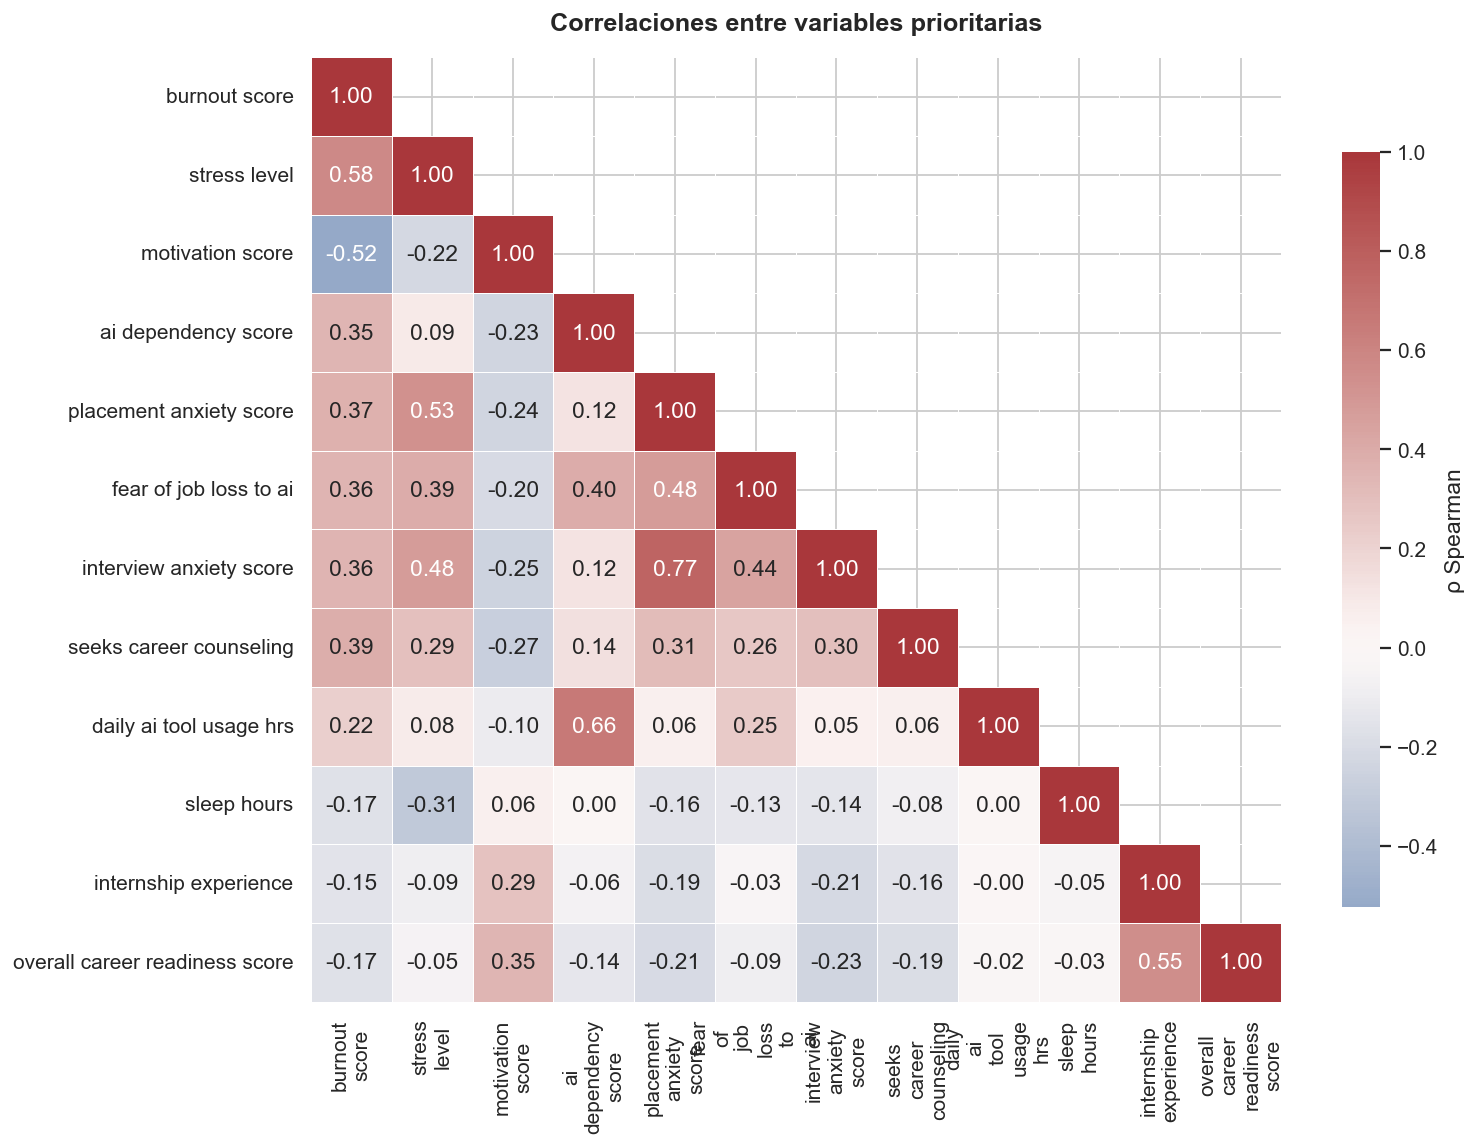

In [12]:
priority_vars = [
    "burnout_score", "stress_level", "motivation_score",
    "ai_dependency_score", "placement_anxiety_score",
    "fear_of_job_loss_to_ai", "interview_anxiety_score",
    "seeks_career_counseling", "daily_ai_tool_usage_hrs",
    "sleep_hours", "internship_experience",
    "overall_career_readiness_score"
]

corr_matrix = df[priority_vars].corr(method="spearman")

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix, mask=mask, cmap="vlag", center=0,
    annot=True, fmt=".2f", linewidths=0.4,
    cbar_kws={"label": "ρ Spearman", "shrink": 0.8},
    xticklabels=[v.replace("_", "\n") for v in priority_vars],
    yticklabels=[v.replace("_", " ") for v in priority_vars],
    ax=ax
)
ax.set_title("Correlaciones entre variables prioritarias", fontsize=14, fontweight="bold", pad=15)
fig.tight_layout()
fig.savefig(GRAFICOS / "heatmap_variables_prioritarias.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.4 Comparación visual: Burnout por frecuencia de uso de IA

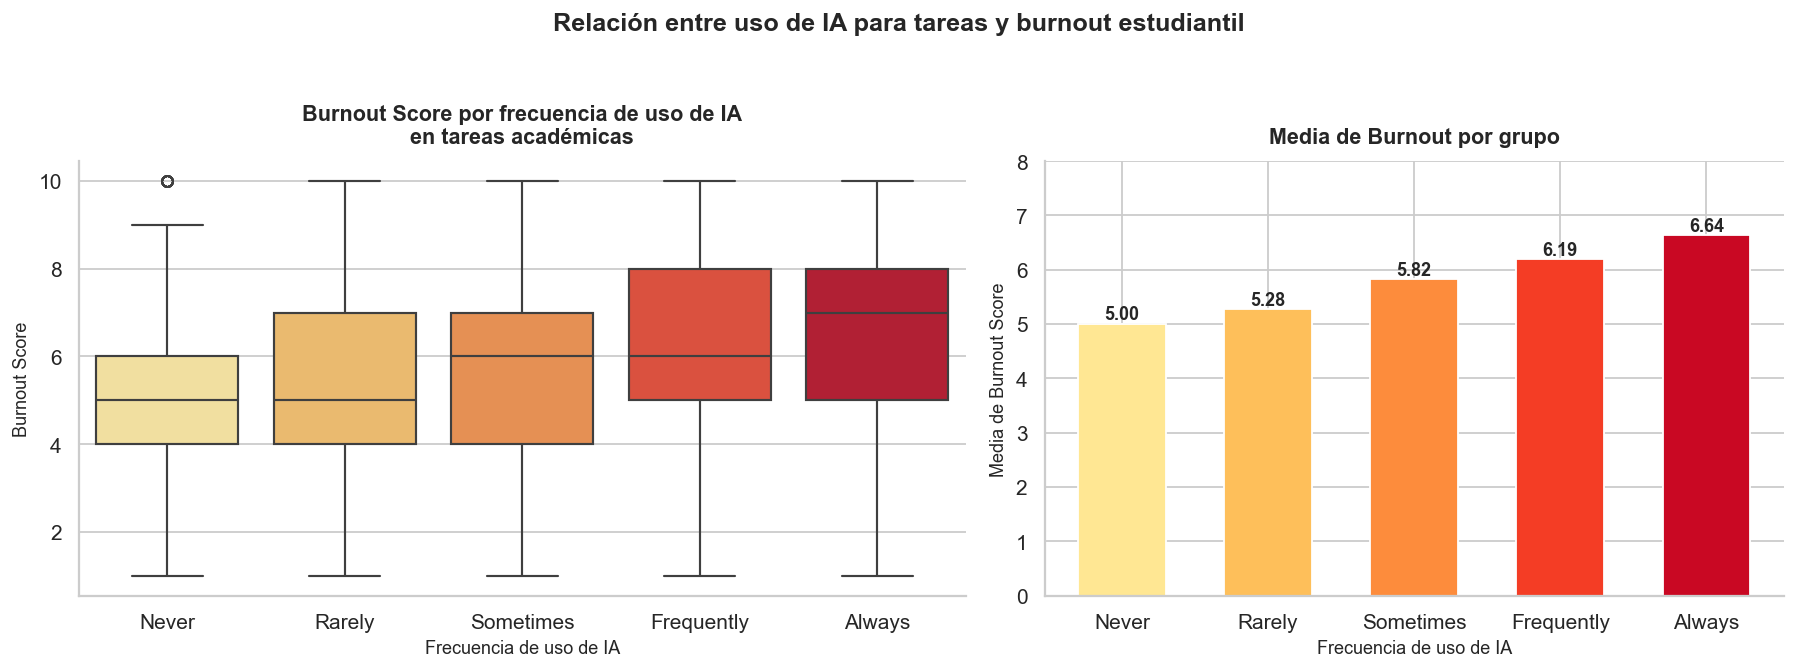

In [13]:
AI_ORDER = ["Never", "Rarely", "Sometimes", "Frequently", "Always"]
df_plot = df.copy()
df_plot["uses_ai_for_assignments"] = pd.Categorical(
    df_plot["uses_ai_for_assignments"], categories=AI_ORDER, ordered=True
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1.2, 1]})

# Boxplot
palette_box = sns.color_palette("YlOrRd", n_colors=5)
sns.boxplot(
    data=df_plot, x="uses_ai_for_assignments", y="burnout_score",
    hue="uses_ai_for_assignments", palette=palette_box,
    linewidth=1.2, legend=False, ax=axes[0]
)
axes[0].set_title("Burnout Score por frecuencia de uso de IA\nen tareas académicas",
                  fontsize=12, fontweight="bold", pad=10)
axes[0].set_xlabel("Frecuencia de uso de IA", fontsize=10)
axes[0].set_ylabel("Burnout Score", fontsize=10)

# Barplot de medias
group_means = df_plot.groupby("uses_ai_for_assignments", observed=False)["burnout_score"].mean()
bars = axes[1].bar(group_means.index.astype(str), group_means.values,
                   color=palette_box, edgecolor="white", width=0.6)
for bar, val in zip(bars, group_means.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.08,
                f"{val:.2f}", ha="center", fontsize=10, fontweight="bold")
axes[1].set_ylim(0, 8)
axes[1].set_title("Media de Burnout por grupo", fontsize=12, fontweight="bold", pad=10)
axes[1].set_xlabel("Frecuencia de uso de IA", fontsize=10)
axes[1].set_ylabel("Media de Burnout Score", fontsize=10)

for ax in axes:
    sns.despine(ax=ax)

fig.suptitle("Relación entre uso de IA para tareas y burnout estudiantil",
             fontsize=14, fontweight="bold", y=1.03)
fig.tight_layout()
fig.savefig(GRAFICOS / "burnout_vs_uso_ia_resumen.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5. Tabla consolidada de variables candidatas para modelamiento

In [14]:
display(Markdown("### Variables candidatas agrupadas por bloque conceptual"))

resumen_candidatas = candidatas_df[
    ["variable", "bloque", "tipo_dato", "metrica_observada", "valor_observado", "direccion_observada"]
].copy()
resumen_candidatas.columns = ["Variable", "Bloque", "Tipo", "Métrica", "Valor", "Dirección"]

display(resumen_candidatas.style.hide(axis='index'))

### Variables candidatas agrupadas por bloque conceptual

Variable,Bloque,Tipo,Métrica,Valor,Dirección
stress_level,Subjetiva / autopercepción,numérica,Spearman,0.577000,positiva
motivation_score,Subjetiva / autopercepción,numérica,Spearman,-0.524000,negativa
placement_anxiety_score,Subjetiva / autopercepción,numérica,Spearman,0.370000,positiva
interview_anxiety_score,Subjetiva / autopercepción,numérica,Spearman,0.356000,positiva
fear_of_job_loss_to_ai,Subjetiva / autopercepción,numérica,Spearman,0.355000,positiva
ai_dependency_score,Subjetiva / autopercepción,numérica,Spearman,0.351000,positiva
daily_ai_tool_usage_hrs,Conductual / hábitos,numérica,Spearman,0.225000,positiva
sleep_hours,Conductual / hábitos,numérica,Spearman,-0.167000,negativa
social_media_hrs_per_day,Conductual / hábitos,numérica,Spearman,0.098000,positiva
daily_study_hours,Conductual / hábitos,numérica,Spearman,-0.112000,negativa


In [15]:
# ── Resumen visual por bloque ─────────────────────────────────────────────────
bloque_summary = candidatas_df.groupby("bloque").agg(
    n_variables=("variable", "count"),
    media_valor=("valor_observado", "mean"),
    max_valor=("valor_observado", "max")
).reset_index()
bloque_summary.columns = ["Bloque conceptual", "N° variables", "Valor medio", "Valor máximo"]

display(Markdown("### Resumen por bloque conceptual"))
display(bloque_summary.style.hide(axis='index').format({
    "Valor medio": "{:.3f}", "Valor máximo": "{:.3f}"
}))

### Resumen por bloque conceptual

Bloque conceptual,N° variables,Valor medio,Valor máximo
Conductual / hábitos,9,0.217,1.640
Contextual / demográfica,8,0.287,0.870
Subjetiva / autopercepción,6,0.247,0.577


---
## 6. Conclusiones generales del EDA

In [16]:
display(Markdown("""
### 6.1 Sobre la calidad de los datos

1. **El dataset es de alta calidad estructural.** No se encontraron duplicados exactos, los nombres de columnas estaban normalizados y los tipos de dato son coherentes con la documentación.
2. **Los valores nulos se concentraron en 5 variables** (principalmente `primary_ai_tools_used` con 21.4% faltante). La estrategia de eliminación por filas redujo el dataset un 25.9% pero mantuvo más de 11,000 registros.
3. **No se detectaron variables con baja variabilidad**, lo cual indica que todas las variables aportan información diferenciadora.
4. **Los outliers son moderados** y parecen representar variabilidad natural, no errores de captura.

### 6.2 Sobre las distribuciones

5. **La mayoría de variables numéricas son aproximadamente simétricas** (17 de 22), lo cual favorece análisis estadísticos estándar.
6. **Variables con sesgo derecho** incluyen `seeks_career_counseling` (binaria), `skill_development_courses_taken` y `self_learning_hours_per_week`, lo cual indica que la mayoría de estudiantes toma pocos cursos y dedica pocas horas extra.
7. **`burnout_score` tiene distribución simétrica** centrada en ~5.6 (escala 1-10), con desviación estándar de 2.06, lo que sugiere buena dispersión para modelamiento.

### 6.3 Sobre las relaciones con burnout

8. **Las variables de autopercepción dominan** la relación con burnout (ρ ≥ 0.35 en 6 variables). Esto es conceptualmente esperable pero confirma coherencia interna.
9. **El eje IA-burnout está bien soportado:** `ai_dependency_score` (ρ=0.351), `daily_ai_tool_usage_hrs` (ρ=0.225) y `uses_ai_for_assignments` (diferencia de medias=1.64) muestran una relación consistente entre uso/dependencia de IA y burnout.
10. **`motivation_score` tiene relación inversa fuerte** (ρ=−0.524), posicionándose como un potencial factor protector.
11. **Los estudiantes de CS/IT, universidades Tier 3 y usuarios frecuentes de IA** presentan los mayores niveles de burnout promedio.
12. **Género, zona (urbana/rural) y tipo de grado** no muestran diferencias significativas en burnout.
"""))


### 6.1 Sobre la calidad de los datos

1. **El dataset es de alta calidad estructural.** No se encontraron duplicados exactos, los nombres de columnas estaban normalizados y los tipos de dato son coherentes con la documentación.
2. **Los valores nulos se concentraron en 5 variables** (principalmente `primary_ai_tools_used` con 21.4% faltante). La estrategia de eliminación por filas redujo el dataset un 25.9% pero mantuvo más de 11,000 registros.
3. **No se detectaron variables con baja variabilidad**, lo cual indica que todas las variables aportan información diferenciadora.
4. **Los outliers son moderados** y parecen representar variabilidad natural, no errores de captura.

### 6.2 Sobre las distribuciones

5. **La mayoría de variables numéricas son aproximadamente simétricas** (17 de 22), lo cual favorece análisis estadísticos estándar.
6. **Variables con sesgo derecho** incluyen `seeks_career_counseling` (binaria), `skill_development_courses_taken` y `self_learning_hours_per_week`, lo cual indica que la mayoría de estudiantes toma pocos cursos y dedica pocas horas extra.
7. **`burnout_score` tiene distribución simétrica** centrada en ~5.6 (escala 1-10), con desviación estándar de 2.06, lo que sugiere buena dispersión para modelamiento.

### 6.3 Sobre las relaciones con burnout

8. **Las variables de autopercepción dominan** la relación con burnout (ρ ≥ 0.35 en 6 variables). Esto es conceptualmente esperable pero confirma coherencia interna.
9. **El eje IA-burnout está bien soportado:** `ai_dependency_score` (ρ=0.351), `daily_ai_tool_usage_hrs` (ρ=0.225) y `uses_ai_for_assignments` (diferencia de medias=1.64) muestran una relación consistente entre uso/dependencia de IA y burnout.
10. **`motivation_score` tiene relación inversa fuerte** (ρ=−0.524), posicionándose como un potencial factor protector.
11. **Los estudiantes de CS/IT, universidades Tier 3 y usuarios frecuentes de IA** presentan los mayores niveles de burnout promedio.
12. **Género, zona (urbana/rural) y tipo de grado** no muestran diferencias significativas en burnout.


---
## 7. Limitaciones del dataset

In [17]:
display(Markdown("""
### Limitaciones identificadas

| # | Limitación | Impacto | Mitigación aplicada |
|---|-----------|---------|--------------------|
| 1 | **Dataset sintético** generado mediante *latent trait modeling* con ruido controlado | Las relaciones descubiertas reflejan la estructura de generación, no necesariamente la realidad | Interpretar hallazgos como patrones del dataset, no como conclusiones causales |
| 2 | **21.4% de valores faltantes** en `primary_ai_tools_used` | La eliminación por filas redujo el dataset un 25.9% | Se mantuvieron >11K registros; suficiente para análisis descriptivo |
| 3 | **Variables de autopercepción correlacionadas entre sí** (multicolinealidad potencial) | Puede inflar la importancia aparente de variables subjetivas | Agrupar por bloques conceptuales para evitar redundancia interpretativa |
| 4 | **No hay variable temporal** (corte transversal) | No es posible establecer causalidad ni tendencias temporales | Limitarse a asociaciones descriptivas |
| 5 | **Escalas ordinales tratadas como numéricas** (burnout 1-10, stress 1-10) | Se usó Spearman en lugar de Pearson, pero el supuesto de intervalo igual persiste | Se priorizó Spearman; para modelamiento avanzado considerar ordinales |
| 6 | **`seeks_career_counseling` codificada como float** (0.0/1.0) en lugar de bool | Puede causar confusión en análisis estadísticos | Se trata como binaria en las interpretaciones |
| 7 | **No se tiene información sobre la institución educativa** ni país | Limita la generalización de los hallazgos | Interpretar como tendencias del dataset específico |
"""))


### Limitaciones identificadas

| # | Limitación | Impacto | Mitigación aplicada |
|---|-----------|---------|--------------------|
| 1 | **Dataset sintético** generado mediante *latent trait modeling* con ruido controlado | Las relaciones descubiertas reflejan la estructura de generación, no necesariamente la realidad | Interpretar hallazgos como patrones del dataset, no como conclusiones causales |
| 2 | **21.4% de valores faltantes** en `primary_ai_tools_used` | La eliminación por filas redujo el dataset un 25.9% | Se mantuvieron >11K registros; suficiente para análisis descriptivo |
| 3 | **Variables de autopercepción correlacionadas entre sí** (multicolinealidad potencial) | Puede inflar la importancia aparente de variables subjetivas | Agrupar por bloques conceptuales para evitar redundancia interpretativa |
| 4 | **No hay variable temporal** (corte transversal) | No es posible establecer causalidad ni tendencias temporales | Limitarse a asociaciones descriptivas |
| 5 | **Escalas ordinales tratadas como numéricas** (burnout 1-10, stress 1-10) | Se usó Spearman en lugar de Pearson, pero el supuesto de intervalo igual persiste | Se priorizó Spearman; para modelamiento avanzado considerar ordinales |
| 6 | **`seeks_career_counseling` codificada como float** (0.0/1.0) en lugar de bool | Puede causar confusión en análisis estadísticos | Se trata como binaria en las interpretaciones |
| 7 | **No se tiene información sobre la institución educativa** ni país | Limita la generalización de los hallazgos | Interpretar como tendencias del dataset específico |


---
## 8. Próximos pasos para modelamiento

### 8.1 Propuesta general

In [18]:
display(Markdown("""
### Próximos pasos propuestos

| Paso | Descripción | Prioridad |
|------|------------|----------|
| 1 | **Discretización de variables continuas** para reglas de asociación (Apriori / FP-Growth) | Alta |
| 2 | **Minería de reglas de asociación** enfocada en perfiles de burnout alto vs bajo | Alta |
| 3 | **Análisis de segmentación / clustering** para identificar perfiles de estudiantes | Media |
| 4 | **Modelo predictivo supervisado** (regresión o clasificación) de burnout | Media |
| 5 | **Validación cruzada** de las reglas encontradas contra subconjuntos del dataset | Media |
| 6 | **Considerar imputación** de valores faltantes como alternativa a eliminación | Baja |
"""))


### Próximos pasos propuestos

| Paso | Descripción | Prioridad |
|------|------------|----------|
| 1 | **Discretización de variables continuas** para reglas de asociación (Apriori / FP-Growth) | Alta |
| 2 | **Minería de reglas de asociación** enfocada en perfiles de burnout alto vs bajo | Alta |
| 3 | **Análisis de segmentación / clustering** para identificar perfiles de estudiantes | Media |
| 4 | **Modelo predictivo supervisado** (regresión o clasificación) de burnout | Media |
| 5 | **Validación cruzada** de las reglas encontradas contra subconjuntos del dataset | Media |
| 6 | **Considerar imputación** de valores faltantes como alternativa a eliminación | Baja |


### 8.2 Recomendación de problemática para reglas de asociación

In [19]:
display(Markdown("""
## Propuesta: Reglas de asociación para perfiles de burnout estudiantil

### Problemática propuesta

**"¿Qué combinaciones de comportamientos de uso de IA, hábitos de estudio y características académicas se asocian con niveles altos de burnout en estudiantes universitarios?"**

### Justificación

El EDA ha demostrado que:
- Existe una relación consistente entre **dependencia de IA** y **burnout** (ρ=0.351).
- El **uso frecuente de IA para tareas** muestra la mayor diferencia entre grupos (media de burnout: 6.64 "Always" vs 5.00 "Never").
- Variables **conductuales** (horas de uso de IA, sueño, búsqueda laboral) aportan información no redundante.
- Las variables son **naturalmente categorizables** o fácilmente discretizables.

### Esquema de discretización propuesto

| Variable | Categorías propuestas |
|----------|----------------------|
| `burnout_score` | **Bajo** (1-4), **Medio** (5-7), **Alto** (8-10) |
| `stress_level` | **Bajo** (1-4), **Medio** (5-7), **Alto** (8-10) |
| `ai_dependency_score` | **Bajo** (1-4), **Medio** (5-7), **Alto** (8-10) |
| `motivation_score` | **Bajo** (1-4), **Medio** (5-7), **Alto** (8-10) |
| `daily_ai_tool_usage_hrs` | **Bajo** (<2h), **Medio** (2-4h), **Alto** (>4h) |
| `sleep_hours` | **Bajo** (<6h), **Normal** (6-8h), **Alto** (>8h) |
| `placement_anxiety_score` | **Bajo** (1-4), **Medio** (5-7), **Alto** (8-10) |
| `uses_ai_for_assignments` | Ya es categórica |
| `stream` | Ya es categórica |
| `college_tier` | Ya es categórica |

### Reglas esperadas (ejemplos hipotéticos)

```
{stress_alto, ai_dependency_alta, motivation_bajo} → {burnout_alto}  (soporte: X%, confianza: Y%)
{uso_ia_always, sleep_bajo, CS/IT} → {burnout_alto}                 (soporte: X%, confianza: Y%)
{motivation_alto, sleep_normal, ai_dependency_bajo} → {burnout_bajo} (soporte: X%, confianza: Y%)
```

### Algoritmo recomendado

- **FP-Growth** por eficiencia con datasets de este tamaño (11K registros).
- Parámetros iniciales sugeridos: `min_support=0.05`, `min_confidence=0.6`, `min_lift=1.2`.
- Biblioteca Python: `mlxtend.frequent_patterns`.

### Valor del análisis

Las reglas de asociación complementan el análisis correlacional al:
1. **Identificar combinaciones** de factores (no solo relaciones individuales).
2. **Generar perfiles interpretables** para intervención (ej: "estudiantes de CS/IT con alta dependencia de IA y bajo sueño").
3. **Descubrir patrones no lineales** que las correlaciones no capturan.
"""))


## Propuesta: Reglas de asociación para perfiles de burnout estudiantil

### Problemática propuesta

**"¿Qué combinaciones de comportamientos de uso de IA, hábitos de estudio y características académicas se asocian con niveles altos de burnout en estudiantes universitarios?"**

### Justificación

El EDA ha demostrado que:
- Existe una relación consistente entre **dependencia de IA** y **burnout** (ρ=0.351).
- El **uso frecuente de IA para tareas** muestra la mayor diferencia entre grupos (media de burnout: 6.64 "Always" vs 5.00 "Never").
- Variables **conductuales** (horas de uso de IA, sueño, búsqueda laboral) aportan información no redundante.
- Las variables son **naturalmente categorizables** o fácilmente discretizables.

### Esquema de discretización propuesto

| Variable | Categorías propuestas |
|----------|----------------------|
| `burnout_score` | **Bajo** (1-4), **Medio** (5-7), **Alto** (8-10) |
| `stress_level` | **Bajo** (1-4), **Medio** (5-7), **Alto** (8-10) |
| `ai_dependency_score` | **Bajo** (1-4), **Medio** (5-7), **Alto** (8-10) |
| `motivation_score` | **Bajo** (1-4), **Medio** (5-7), **Alto** (8-10) |
| `daily_ai_tool_usage_hrs` | **Bajo** (<2h), **Medio** (2-4h), **Alto** (>4h) |
| `sleep_hours` | **Bajo** (<6h), **Normal** (6-8h), **Alto** (>8h) |
| `placement_anxiety_score` | **Bajo** (1-4), **Medio** (5-7), **Alto** (8-10) |
| `uses_ai_for_assignments` | Ya es categórica |
| `stream` | Ya es categórica |
| `college_tier` | Ya es categórica |

### Reglas esperadas (ejemplos hipotéticos)

```
{stress_alto, ai_dependency_alta, motivation_bajo} → {burnout_alto}  (soporte: X%, confianza: Y%)
{uso_ia_always, sleep_bajo, CS/IT} → {burnout_alto}                 (soporte: X%, confianza: Y%)
{motivation_alto, sleep_normal, ai_dependency_bajo} → {burnout_bajo} (soporte: X%, confianza: Y%)
```

### Algoritmo recomendado

- **FP-Growth** por eficiencia con datasets de este tamaño (11K registros).
- Parámetros iniciales sugeridos: `min_support=0.05`, `min_confidence=0.6`, `min_lift=1.2`.
- Biblioteca Python: `mlxtend.frequent_patterns`.

### Valor del análisis

Las reglas de asociación complementan el análisis correlacional al:
1. **Identificar combinaciones** de factores (no solo relaciones individuales).
2. **Generar perfiles interpretables** para intervención (ej: "estudiantes de CS/IT con alta dependencia de IA y bajo sueño").
3. **Descubrir patrones no lineales** que las correlaciones no capturan.


---
## 9. Informe final del EDA — resumen ejecutivo

In [20]:
# ── Generar y guardar el informe final como markdown ─────────────────────────
informe_final = """
# Informe Final del EDA — AI Dependency, Career Anxiety and Student Burnout

## 1. Descripción del Dataset

- **Fuente:** Dataset sintético generado mediante *latent trait modeling* con ruido controlado.
- **Registros originales:** 15,000 | **Tras limpieza:** 11,119 (25.9% eliminados por valores nulos).
- **Variables:** 30 columnas (22 numéricas, 8 categóricas).
- **Variable objetivo (metadata):** `overall_career_readiness_score`.
- **Variable central del EDA relacional:** `burnout_score`.

## 2. Calidad de Datos

- Sin duplicados exactos.
- 5 variables con valores nulos; `primary_ai_tools_used` con 21.4% faltante.
- Tratamiento: eliminación de filas con NA.
- Sin variables de baja variabilidad.
- Outliers moderados (máximo: `internship_experience` con 5.24%).

## 3. Hallazgos Principales

### Distribuciones
- 17 de 22 variables numéricas son aproximadamente simétricas.
- `burnout_score` tiene media=5.64, mediana=6.0 y buena dispersión (σ=2.06).
- Variables sesgadas: `seeks_career_counseling`, `skill_development_courses_taken`, `age`.

### Relaciones con Burnout

**Variables más asociadas (Spearman):**
1. `stress_level` (ρ=+0.577) — la más fuerte.
2. `motivation_score` (ρ=−0.524) — relación protectora.
3. `seeks_career_counseling` (ρ=+0.386).
4. `placement_anxiety_score` (ρ=+0.370).
5. `interview_anxiety_score` (ρ=+0.356).
6. `fear_of_job_loss_to_ai` (ρ=+0.355).
7. `ai_dependency_score` (ρ=+0.351).

**Patrones por grupo:**
- Uso de IA "Always" → burnout promedio 6.64 vs 5.00 de "Never" (+1.64 puntos).
- Estudiantes de CS/IT → mayor burnout (5.87) vs otras áreas.
- Universidades Tier 3 → mayor burnout (5.76) que Tier 1 (5.30).
- Género, zona y tipo de grado no muestran diferencias relevantes.

## 4. Limitaciones

1. Dataset sintético (las relaciones reflejan la estructura de generación).
2. Diseño transversal (no se puede establecer causalidad).
3. Multicolinealidad entre variables subjetivas.
4. 25.9% de datos eliminados por valores nulos.
5. Escalas ordinales tratadas como numéricas.

## 5. Recomendaciones

### Para reglas de asociación

**Problemática recomendada:** Identificar combinaciones de comportamientos de uso de IA, hábitos de estudio y características académicas asociadas a burnout alto.

- Discretizar variables continuas en 3 niveles (Bajo/Medio/Alto).
- Usar FP-Growth con min_support=0.05, min_confidence=0.6.
- Variables prioritarias: `burnout_score`, `stress_level`, `ai_dependency_score`, `motivation_score`, `uses_ai_for_assignments`, `daily_ai_tool_usage_hrs`, `sleep_hours`, `stream`.

### Para modelamiento predictivo

- Variable objetivo: `burnout_score` (discretizada o continua).
- Features prioritarios: los 7 primeros del ranking de correlaciones.
- Considerar separar variables subjetivas de conductuales para evitar información redundante.

## 6. Artefactos Generados

| Artefacto | Ruta |
|-----------|------|
| Dataset limpio | `data/processed/dataset_limpio.csv` |
| Estadísticas descriptivas | `outputs/tablas/estadisticas_descriptivas.csv` |
| Reporte de outliers | `outputs/tablas/reporte_outliers.csv` |
| Forma de distribuciones | `outputs/tablas/forma_distribuciones.csv` |
| Ranking de correlaciones | `outputs/tablas/ranking_correlaciones_burnout.csv` |
| Variables candidatas | `outputs/tablas/variables_candidatas_modelamiento.csv` |
| Comparaciones por grupo | `outputs/tablas/burnout_por_*.csv` |
| Gráficos univariados | `outputs/graficos/univar_*.png`, `bar_*.png` |
| Gráficos de síntesis | `outputs/graficos/panel_variables_clave.png`, `top10_correlaciones_burnout.png`, `heatmap_variables_prioritarias.png` |
| Informe final | `outputs/reportes/informe_final_eda.md` |
"""

informe_path = REPORTES / "informe_final_eda.md"
informe_path.write_text(informe_final.strip(), encoding="utf-8")
print(f"✅ Informe final guardado en: {informe_path}")

✅ Informe final guardado en: C:\Users\vivi_\OneDrive\Documentos\GitHub\proyecto-ingenieria-datos\outputs\reportes\informe_final_eda.md


---
## 10. Dashboard visual de cierre

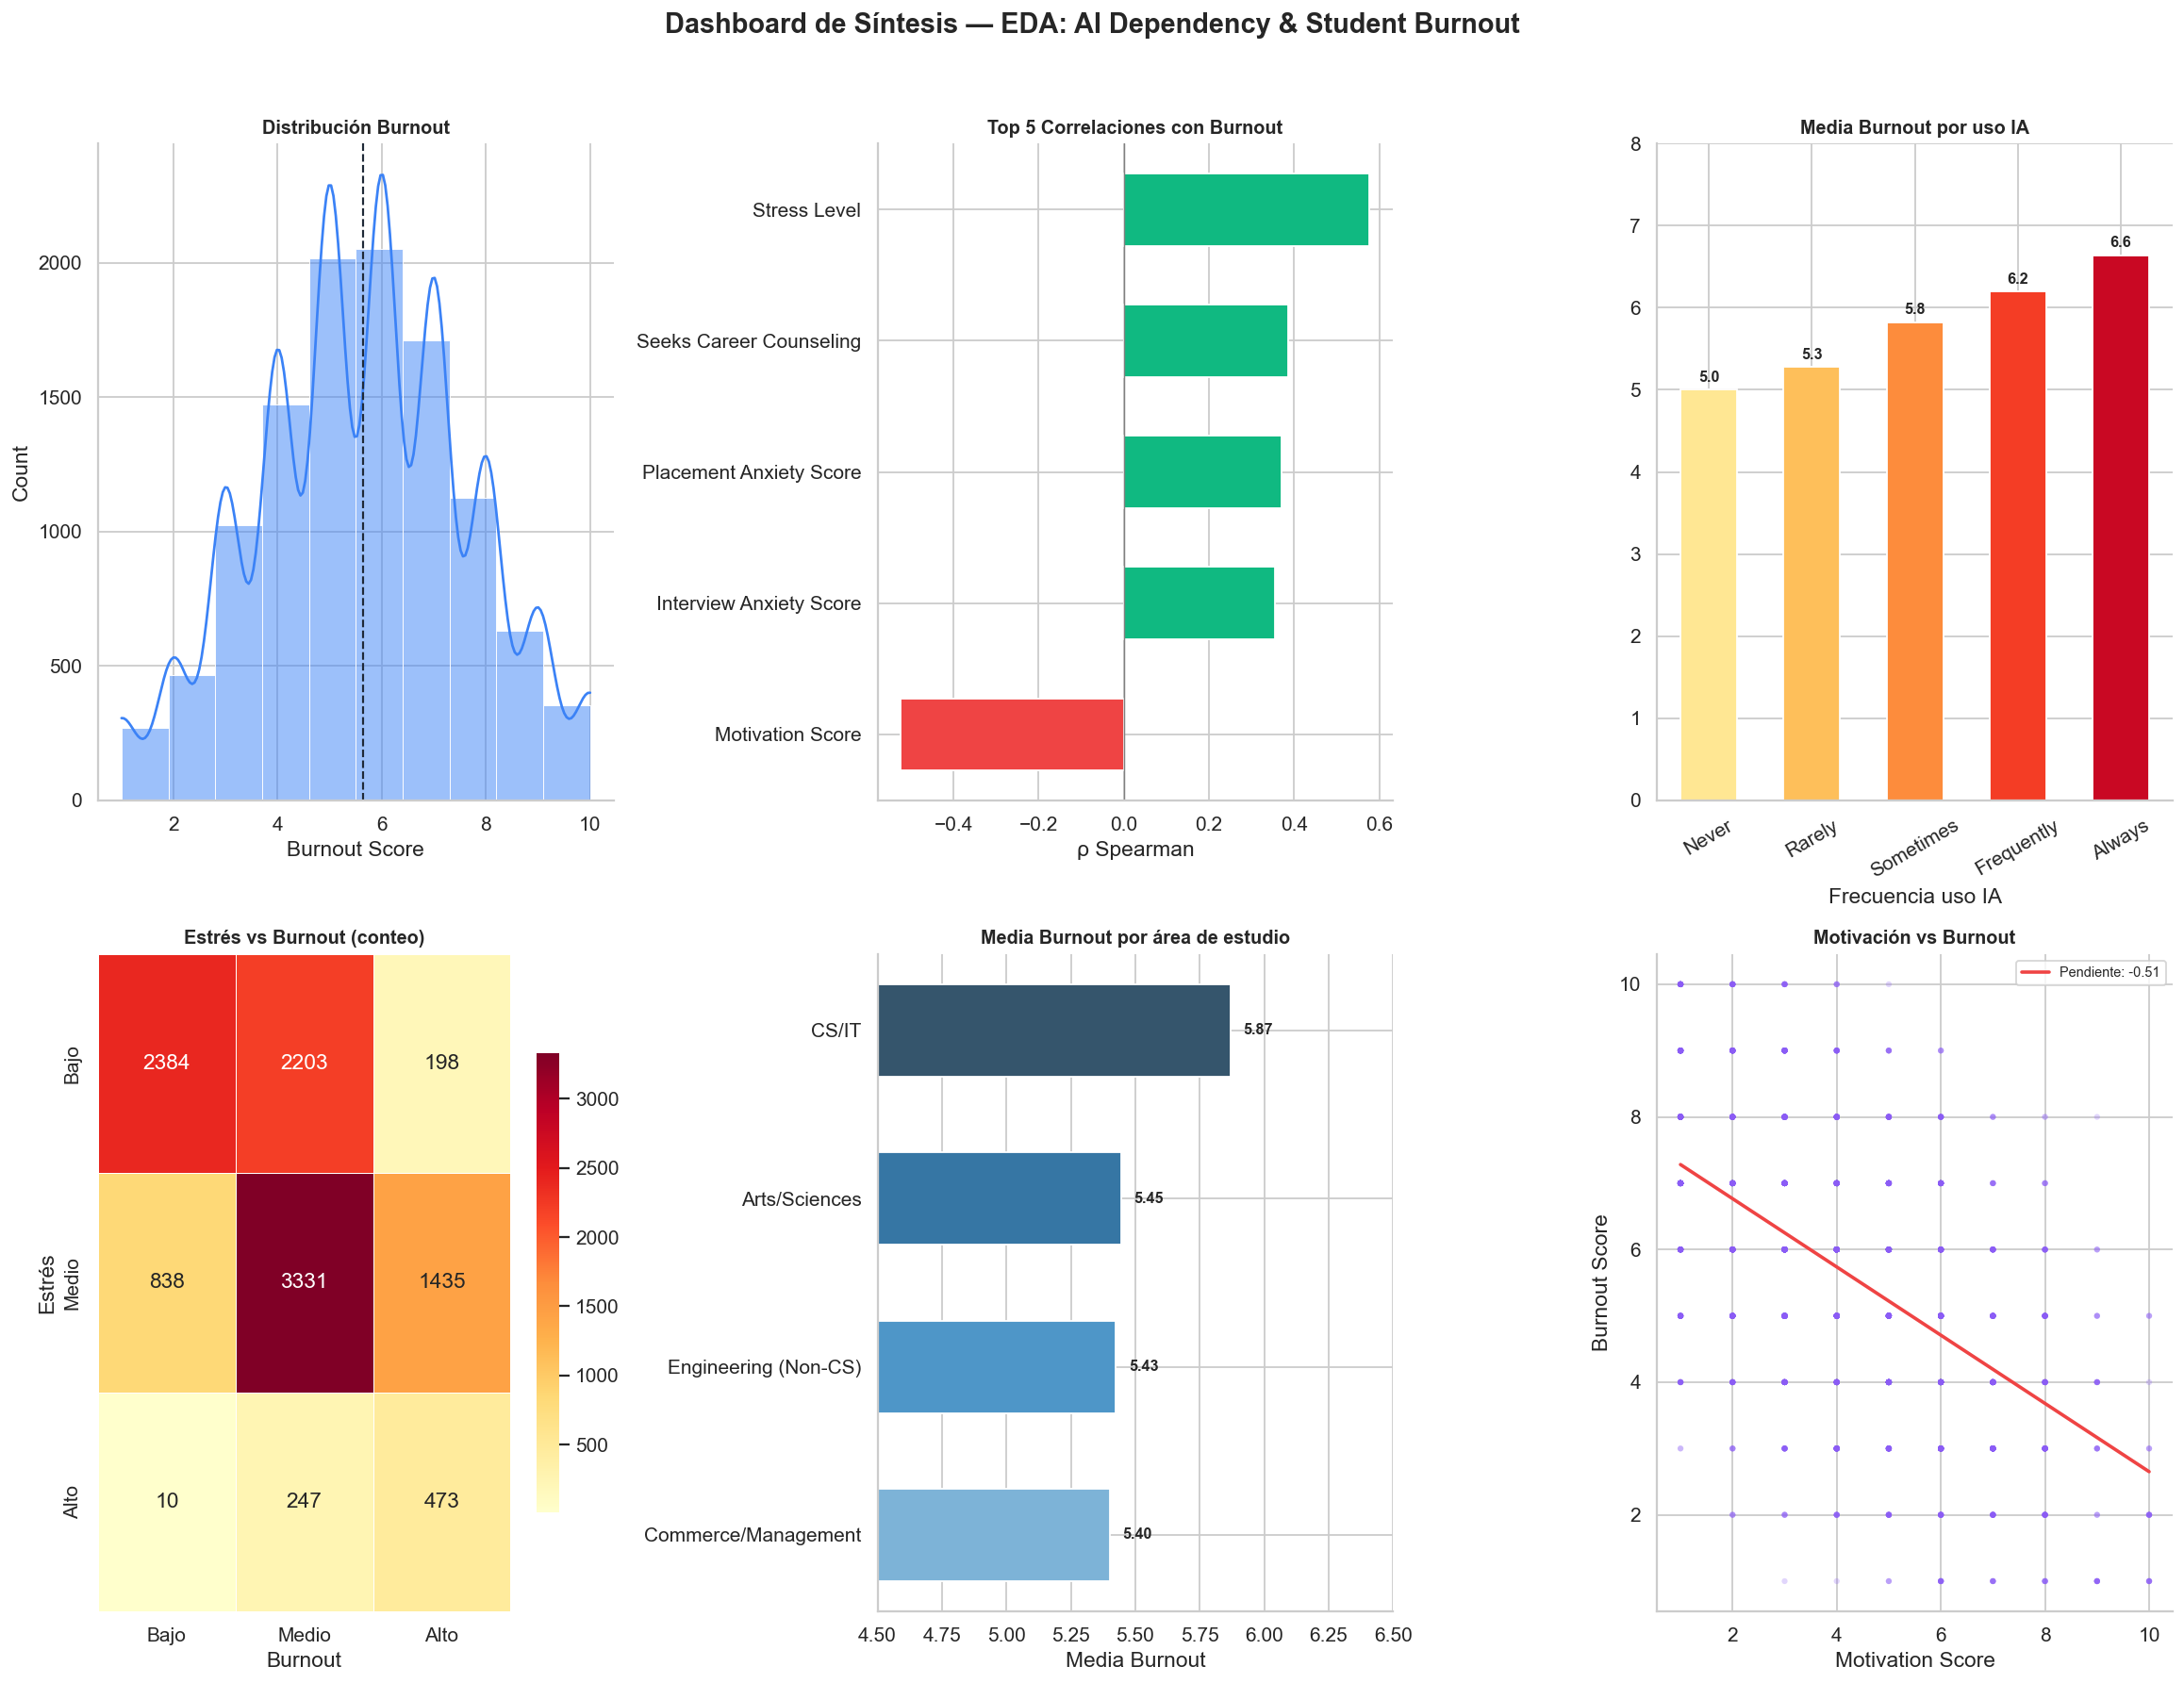


✅ Dashboard guardado en: outputs/graficos/dashboard_sintesis_eda.png


In [21]:
# ── Panel final con los gráficos más relevantes del EDA ─────────────────────
fig = plt.figure(figsize=(18, 14))
fig.suptitle("Dashboard de Síntesis — EDA: AI Dependency & Student Burnout",
             fontsize=16, fontweight="bold", y=0.98)

# ── 1. Distribución de burnout ────────────────────────────────────────────────
ax1 = fig.add_subplot(2, 3, 1)
sns.histplot(df["burnout_score"], bins=10, kde=True, color="#3B82F6",
             edgecolor="white", linewidth=0.5, ax=ax1)
ax1.axvline(df["burnout_score"].mean(), color="#1F2937", ls="--", lw=1.2)
ax1.set_title("Distribución Burnout", fontsize=11, fontweight="bold")
ax1.set_xlabel("Burnout Score")
sns.despine(ax=ax1)

# ── 2. Top 5 correlaciones ────────────────────────────────────────────────────
ax2 = fig.add_subplot(2, 3, 2)
top5 = ranking_df.head(5).sort_values("correlacion_spearman")
cols_bar = ["#10B981" if v > 0 else "#EF4444" for v in top5["correlacion_spearman"]]
ax2.barh(top5["variable"].str.replace("_", " ").str.title(),
         top5["correlacion_spearman"], color=cols_bar, edgecolor="white", height=0.55)
ax2.axvline(0, color="grey", lw=0.8)
ax2.set_title("Top 5 Correlaciones con Burnout", fontsize=11, fontweight="bold")
ax2.set_xlabel("ρ Spearman")
sns.despine(ax=ax2)

# ── 3. Burnout por uso de IA ──────────────────────────────────────────────────
ax3 = fig.add_subplot(2, 3, 3)
means_ia = df_plot.groupby("uses_ai_for_assignments", observed=False)["burnout_score"].mean()
ax3.bar(means_ia.index.astype(str), means_ia.values,
        color=sns.color_palette("YlOrRd", 5), edgecolor="white", width=0.55)
for i, (cat, val) in enumerate(means_ia.items()):
    ax3.text(i, val + 0.1, f"{val:.1f}", ha="center", fontsize=9, fontweight="bold")
ax3.set_ylim(0, 8)
ax3.set_title("Media Burnout por uso IA", fontsize=11, fontweight="bold")
ax3.set_xlabel("Frecuencia uso IA")
ax3.tick_params(axis="x", rotation=30)
sns.despine(ax=ax3)

# ── 4. Stress vs Burnout ──────────────────────────────────────────────────────
ax4 = fig.add_subplot(2, 3, 4)
contingency = pd.crosstab(
    pd.cut(df["stress_level"], bins=[0, 4, 7, 10], labels=["Bajo", "Medio", "Alto"]),
    pd.cut(df["burnout_score"], bins=[0, 4, 7, 10], labels=["Bajo", "Medio", "Alto"])
)
sns.heatmap(contingency, annot=True, fmt="d", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"shrink": 0.7}, ax=ax4)
ax4.set_title("Estrés vs Burnout (conteo)", fontsize=11, fontweight="bold")
ax4.set_xlabel("Burnout")
ax4.set_ylabel("Estrés")

# ── 5. Burnout por stream ─────────────────────────────────────────────────────
ax5 = fig.add_subplot(2, 3, 5)
stream_means = df.groupby("stream")["burnout_score"].mean().sort_values()
ax5.barh(stream_means.index, stream_means.values,
         color=sns.color_palette("Blues_d", len(stream_means)),
         edgecolor="white", height=0.55)
for i, (idx, val) in enumerate(stream_means.items()):
    ax5.text(val + 0.05, i, f"{val:.2f}", va="center", fontsize=9, fontweight="bold")
ax5.set_title("Media Burnout por área de estudio", fontsize=11, fontweight="bold")
ax5.set_xlabel("Media Burnout")
ax5.set_xlim(4.5, 6.5)
sns.despine(ax=ax5)

# ── 6. Motivation vs Burnout scatter ──────────────────────────────────────────
ax6 = fig.add_subplot(2, 3, 6)
sample = df.sample(2000, random_state=42)
ax6.scatter(sample["motivation_score"], sample["burnout_score"],
            alpha=0.25, s=12, color="#8B5CF6", edgecolors="none")
z = np.polyfit(sample["motivation_score"], sample["burnout_score"], 1)
x_line = np.linspace(1, 10, 50)
ax6.plot(x_line, np.polyval(z, x_line), color="#EF4444", lw=2, label=f"Pendiente: {z[0]:.2f}")
ax6.legend(fontsize=8)
ax6.set_title("Motivación vs Burnout", fontsize=11, fontweight="bold")
ax6.set_xlabel("Motivation Score")
ax6.set_ylabel("Burnout Score")
sns.despine(ax=ax6)

fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(GRAFICOS / "dashboard_sintesis_eda.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n✅ Dashboard guardado en: outputs/graficos/dashboard_sintesis_eda.png")

In [22]:
display(Markdown("""
---
## ✅ Resumen de entregables generados por este notebook

| Entregable | Archivo | Estado |
|-----------|---------|--------|
| Informe final del EDA | `outputs/reportes/informe_final_eda.md` | ✅ Generado |
| Dashboard de síntesis (presentación visual) | `outputs/graficos/dashboard_sintesis_eda.png` | ✅ Generado |
| Panel de variables clave | `outputs/graficos/panel_variables_clave.png` | ✅ Generado |
| Top 10 correlaciones con burnout | `outputs/graficos/top10_correlaciones_burnout.png` | ✅ Generado |
| Heatmap de variables prioritarias | `outputs/graficos/heatmap_variables_prioritarias.png` | ✅ Generado |
| Burnout vs uso de IA (resumen) | `outputs/graficos/burnout_vs_uso_ia_resumen.png` | ✅ Generado |
| Conclusiones generales | Secciones 6 de este notebook | ✅ Documentado |
| Limitaciones del dataset | Sección 7 de este notebook | ✅ Documentado |
| Próximos pasos | Sección 8 de este notebook | ✅ Documentado |
| Recomendación de reglas de asociación | Sección 8.2 de este notebook | ✅ Documentado |
"""))


---
## ✅ Resumen de entregables generados por este notebook

| Entregable | Archivo | Estado |
|-----------|---------|--------|
| Informe final del EDA | `outputs/reportes/informe_final_eda.md` | ✅ Generado |
| Dashboard de síntesis (presentación visual) | `outputs/graficos/dashboard_sintesis_eda.png` | ✅ Generado |
| Panel de variables clave | `outputs/graficos/panel_variables_clave.png` | ✅ Generado |
| Top 10 correlaciones con burnout | `outputs/graficos/top10_correlaciones_burnout.png` | ✅ Generado |
| Heatmap de variables prioritarias | `outputs/graficos/heatmap_variables_prioritarias.png` | ✅ Generado |
| Burnout vs uso de IA (resumen) | `outputs/graficos/burnout_vs_uso_ia_resumen.png` | ✅ Generado |
| Conclusiones generales | Secciones 6 de este notebook | ✅ Documentado |
| Limitaciones del dataset | Sección 7 de este notebook | ✅ Documentado |
| Próximos pasos | Sección 8 de este notebook | ✅ Documentado |
| Recomendación de reglas de asociación | Sección 8.2 de este notebook | ✅ Documentado |
